In [1]:
meta = """Incineroar @ Sitrus Berry
Ability: Intimidate
Level: 50
EVs: 32 HP / 32 Atk / 2 Spe
Adamant Nature
- Flare Blitz
- Darkest Lariat
- Fake Out
- Parting Shot

Sneasler @ White Herb
Ability: Pressure
Level: 50
EVs: 32 Atk / 2 Def / 32 Spe
Adamant Nature
- Dire Claw
- Close Combat
- Fake Out
- Protect

Garchomp @ Choice Scarf
Ability: Rough Skin
Level: 50
EVs: 2 HP / 32 Atk / 32 Spe
Adamant Nature
- Earthquake
- Rock Slide
- Dragon Claw
- Stomping Tantrum

Kingambit @ Black Glasses
Ability: Defiant
Level: 50
EVs: 32 HP / 32 Atk / 2 SpD
Adamant Nature
- Kowtow Cleave
- Sucker Punch
- Low Kick
- Iron Head

Basculegion (M) @ Choice Scarf
Ability: Adaptability
Level: 50
EVs: 2 HP / 32 Atk / 32 Spe
Adamant Nature
- Wave Crash
- Last Respects
- Aqua Jet
- Flip Turn

Sinistcha @ Sitrus Berry
Ability: Hospitality
Level: 50
EVs: 32 HP / 14 Def / 20 SpD
Bold Nature
- Matcha Gotcha
- Life Dew
- Rage Powder
- Trick Room

Aerodactyl @ Focus Sash
Ability: Unnerve
Level: 50
EVs: 2 HP / 32 Atk / 32 Spe
Jolly Nature
- Rock Slide
- Dual Wingbeat
- Tailwind
- Wide Guard

Charizard-Mega-Y @ Charizardite Y
Ability: Drought
Level: 50
EVs: 2 HP / 32 SpA / 32 Spe
Modest Nature
- Protect
- Heat Wave
- Solar Beam
- Weather Ball

Rotom-Wash @ Choice Scarf
Ability: Levitate
Level: 50
EVs: 2 HP / 32 SpA / 32 Spe
Modest Nature
- Electroweb
- Thunderbolt
- Hydro Pump
- Volt Switch

Floette-Mega (F) @ Floettite
Ability: Fairy Aura
Level: 50
EVs: 2 HP / 32 SpA / 32 Spe
Modest Nature
- Protect
- Dazzling Gleam
- Moonblast
- Calm Mind

Milotic @ Leftovers
Ability: Competitive
Level: 50
EVs: 32 HP / 21 Def / 10 SpA / 1 SpD / 2 Spe
Modest Nature
- Scald
- Ice Beam
- Icy Wind
- Protect

Tyranitar-Mega @ Tyranitarite
Ability: Sand Stream
Level: 50
EVs: 2 HP / 32 Atk / 32 Spe
Adamant Nature
- Rock Slide
- Protect
- Knock Off
- Low Kick

Farigiraf @ Sitrus Berry
Ability: Armor Tail
Level: 50
EVs: 32 HP / 2 Def / 32 SpA
Quiet Nature
- Psychic
- Hyper Voice
- Helping Hand
- Trick Room

Archaludon @ Leftovers
Ability: Stamina
Level: 50
EVs: 2 HP / 20 SpA / 32 Spe
Modest Nature
- Electro Shot
- Draco Meteor
- Flash Cannon
- Dragon Pulse

Staraptor-Mega @ Staraptorite
Ability: Intimidate
Level: 50
EVs: 2 HP / 32 Atk / 32 Spe
Jolly Nature
- Protect
- Close Combat
- Brave Bird
- Roost

Pelipper @ Focus Sash
Ability: Drizzle
Level: 50
EVs: 2 HP / 32 SpA / 32 Spe
Modest Nature
- Hurricane
- Weather Ball
- Tailwind
- Protect

Froslass-Mega @ Froslassite
Ability: Snow Warning
Level: 50
EVs: 2 Def / 32 SpA / 32 Spe
Timid Nature
- Shadow Ball
- Blizzard
- Aurora Veil
- Protect
"""

In [2]:
"""
Tyranitar @ Focus Sash
Ability: Sand Stream
Level: 50
EVs: 2 HP / 32 Atk / 32 Spe
Adamant Nature
- Rock Slide
- Protect
- Knock Off
- Low Kick
"""

''

In [ ]:
# Libraries

import math
import re
import matplotlib.pyplot as plt
import numpy as np
import requests
from matplotlib.patches import Patch


# ---------------------------
# Base math helpers
# ---------------------------
def normalize_name(value):
    """
    Converte nomi di mosse o strumenti nel formato slug usato da PokeAPI e dalle mappe interne.
    """
    return (
        value.lower()
        .replace(" ", "-")
        .replace("'", "")
    )


def normalize_pokemon_name(name):
    """
    Converte un nome Pokemon Showdown nel formato atteso da PokeAPI, applicando le eccezioni note per forme regionali, mega e gender form.
    """
    name = (
        name.lower()
        .replace(" ", "-")
        .replace("?", "")
        .replace("'", "")
    )
    return POKEMON_NAME_MAP.get(name, name)


def ev_parser(ev_string):
    """
    Legge una stringa EV in formato Showdown e restituisce la lista [HP, Atk, Def, SpA, SpD, Spe].
    """
    order = ["HP", "Atk", "Def", "SpA", "SpD", "Spe"]
    result = [0] * 6

    for value, stat in re.findall(r"(\d+)\s*(HP|Atk|Def|SpA|SpD|Spe)", ev_string):
        result[order.index(stat)] = int(value)

    return result


def dmg_calc(D):
    # Danno ricevuto da una mossa 100 base power non stab da pkmn con 150 atk/spa
    # 150 statistica atk = 130 base e 31 IV = Garchomp 0 EV/31 IV = Incineroar Adamant 0 EV/31 IV
    """
    Calcola un benchmark semplificato di danno ricevuto da una mossa non STAB da 100 BP con statistica offensiva pari a 150.
    """
    return int(((22 * 150 * 100) / (D * 50)) + 2)


def dmg_calc_adv(A, P, D, STAB):
    # Danno ricevuto da una mossa P base power STAB (boolean) da pkmn con A atk/spa
    """
    Calcola il danno semplificato per una mossa con potenza, statistica offensiva, difesa e modificatore STAB configurabili.
    """
    return int(((22 * A * P) / (D * 50)) + 2) * (1 + 0.5 * STAB)


def k(P, STAB):
    # Costante per avere %HP_left = 1-(k*ATK)/(DEF*HP)
    """
    Restituisce la costante del modello semplificato usata per stimare la percentuale di HP persa al variare di attacco, difesa e HP.
    """
    return (22 * P) * (1 + 0.5 * STAB) / 50


def stat_calc(base_stat, ev, iv, hp_flag, champions=True):
    """
    Calcola una statistica finale a livello 50 partendo da base stat, EV, IV e flag HP; usa la formula custom Champions se richiesto.
    """
    if champions:
        if hp_flag:
            return base_stat + ev + 75
        return base_stat + ev + 20

    if hp_flag:
        return math.floor((2 * base_stat + iv + math.floor(ev / 4)) / 2) + 60
    return math.floor((2 * base_stat + iv + math.floor(ev / 4)) / 2) + 5


def apply_nature(stats, nature):
    """
    Applica il moltiplicatore della natura a una lista di statistiche nel formato [HP, Atk, Def, SpA, SpD, Spe].
    """
    stats = stats.copy()
    inc, dec = NATURE_MODIFIERS.get(nature, (None, None))

    if inc:
        stats[STAT_INDEX[inc]] = int(stats[STAT_INDEX[inc]] * 1.1)
    if dec:
        stats[STAT_INDEX[dec]] = int(stats[STAT_INDEX[dec]] * 0.9)

    return stats


def build_stats(base_stats, evs, nature):
    """
    Costruisce le sei statistiche finali di un Pokemon usando base stats PokeAPI, EV parsati e natura Showdown.
    """
    stats = [
        stat_calc(
            base_stats[stat_name],
            evs[i],
            31,
            i == 0,
        )
        for i, stat_name in enumerate(STAT_LIST)
    ]

    if nature:
        stats = apply_nature(stats, nature)

    return stats


# ---------------------------
# Showdown parsing helpers
# ---------------------------
def parse_showdown_team(team_text):
    """
    Esegue il parsing unico di uno o piu set in formato Pokemon Showdown e restituisce dict normalizzati con nome, item, natura, EV e mosse.
    """
    team = []
    blocks = [block.strip() for block in team_text.strip().split("\n\n") if block.strip()]

    for block in blocks:
        lines = block.splitlines()
        name, separator, item = lines[0].partition(" @ ")

        pokemon = {
            "name": name.strip(),
            "item": normalize_name(item.strip()) if separator else None,
            "nature": None,
            "evs": [0] * 6,
            "moves": [],
        }

        for line in lines[1:]:
            line = line.strip()

            if line.startswith("EVs:"):
                pokemon["evs"] = ev_parser(line.replace("EVs:", "").strip())
            elif line.endswith("Nature"):
                pokemon["nature"] = line.replace(" Nature", "").strip()
            elif line.startswith("- "):
                pokemon["moves"].append(normalize_name(line[2:].strip()))

        team.append(pokemon)

    return team


def parse_showdown_pokemon(showdown_set):
    """
    Estrae il primo Pokemon da un testo Showdown; utile quando l input rappresenta un singolo attacker.
    """
    return parse_showdown_team(showdown_set)[0]


def team_by_name(team):
    """
    Indicizza una lista di Pokemon parsati per nome, cosi le celle possono recuperare rapidamente i dati di un membro del team.
    """
    return {pokemon["name"]: pokemon for pokemon in team}


def build_team_context(team_text):
    """
    Combina parsing Showdown, normalizzazione e lookup PokeAPI in una struttura unica usata dalle analisi successive.
    """
    team = parse_showdown_team(team_text)

    context = {
        "team": team,
        "by_name": team_by_name(team),
        "ev_strings": {},
        "natures": {},
        "moves": {},
        "items": {},
        "base_stats": {},
        "evs": {},
        "stats": {},
        "types": {},
    }

    for pokemon in team:
        name = pokemon["name"]
        api_data = get_pokemon_stats_cached(name)

        context["ev_strings"][name] = format_evs(pokemon["evs"])
        context["natures"][name] = pokemon["nature"]
        context["moves"][name] = pokemon["moves"]
        context["items"][name] = pokemon["item"]
        context["evs"][name] = pokemon["evs"]

        if api_data is None:
            continue

        context["base_stats"][name] = api_data
        context["stats"][name] = build_stats(api_data, pokemon["evs"], pokemon["nature"])
        context["types"][name] = api_data["types"]

    return context


def format_evs(evs):
    """
    Riconverte una lista EV nel formato leggibile HP / Atk / Def, omettendo le statistiche a zero.
    """
    parts = [f"{value} {stat}" for value, stat in zip(evs, STAT_INDEX.keys()) if value]
    return " / ".join(parts)


# ---------------------------
# API/cache helpers
# ---------------------------
def get_pokemon_stats_cached(pokemon_name):
    """
    Recupera base stats e tipi da PokeAPI, salvando il risultato in cache per evitare chiamate ripetute sullo stesso Pokemon.
    """
    pokemon_name = normalize_pokemon_name(pokemon_name)

    if pokemon_name in POKEMON_STATS_CACHE:
        return POKEMON_STATS_CACHE[pokemon_name]

    url = f"https://pokeapi.co/api/v2/pokemon/{pokemon_name}"
    response = requests.get(url)

    if response.status_code != 200:
        print(f"Pokemon {pokemon_name} non trovato")
        return None

    data = response.json()
    stats = {stat["stat"]["name"]: stat["base_stat"] for stat in data["stats"]}
    stats["types"] = [pokemon_type["type"]["name"] for pokemon_type in data["types"]]

    POKEMON_STATS_CACHE[pokemon_name] = stats
    return stats


def get_move_data_cached(move_name):
    """
    Recupera da PokeAPI i dati essenziali di una mossa, applica override locali per casi speciali e salva il risultato in cache.
    """
    move_name = normalize_name(move_name)

    if move_name in POKEMON_MOVE_CACHE:
        return POKEMON_MOVE_CACHE[move_name]

    url = f"https://pokeapi.co/api/v2/move/{move_name}"
    response = requests.get(url)

    if response.status_code != 200:
        return None

    data = response.json()
    move_metadata = data["meta"]
    power = data["power"]

    if move_name == "last-respects":
        power = 100
    elif move_name == "weather-ball":
        power = 100
    elif move_name == "dual-wingbeat":
        power = data["power"] * 2

    result = {
        "power": power,
        "type": data["type"]["name"],
        "damage_class": data["damage_class"]["name"],
        "crit_rate": 0 if move_metadata is None else move_metadata["crit_rate"],
        "targets": 1 if data["target"]["name"] in ["self", "selected-pokemon"] else 2,
    }

    POKEMON_MOVE_CACHE[move_name] = result
    return result


# ---------------------------
# Battle/damage helpers
# ---------------------------
def item_multiplier(move_info, item):
    """
    Restituisce il moltiplicatore di danno dato dallo strumento se lo strumento potenzia la mossa corrente.
    """
    if item is None:
        return 1

    item_boosted_move_type = ITEM_MOVE_TYPE_BOOST.get(item, "any")
    if move_info["type"] == item_boosted_move_type or item_boosted_move_type == "any":
        return ITEM_DAMAGE_MULTIPLIERS.get(item, 1)

    return 1


def adjusted_move_info(move_info, move_name, pokemon_name):
    """
    Crea una copia dei dati mossa e applica aggiustamenti contestuali, per esempio il tipo di Weather Ball sotto meteo noto.
    """
    move_info = move_info.copy()
    normalized_move = normalize_name(move_name)
    normalized_pokemon = normalize_pokemon_name(pokemon_name)

    if normalized_move == "weather-ball":
        if normalized_pokemon == "pelipper":
            move_info["type"] = "water"
        elif normalized_pokemon == "charizard-mega-y":
            move_info["type"] = "fire"

    return move_info


def offensive_modifiers(move_info, move_name, pokemon_name, attacker_types):
    """
    Determina i modificatori offensivi custom del notebook, inclusi STAB, Adaptability, meteo e aura specifiche.
    """
    normalized_move = normalize_name(move_name)
    normalized_pokemon = normalize_pokemon_name(pokemon_name)

    stab = 1 if move_info["type"] in attacker_types or normalized_move == "weather-ball" else 0
    weather = 0

    if stab == 1 and normalized_pokemon == "basculegion-male":
        stab = 2
    elif normalized_pokemon == "charizard-mega-y" and (move_info["type"] == "fire" or normalized_move == "weather-ball"):
        weather = 0.5
    elif normalized_pokemon == "pelipper" and (move_info["type"] == "water" or normalized_move == "weather-ball"):
        weather = 0.5
    elif normalized_move == "electro-shot":
        stab = 1
    elif normalized_pokemon == "floette-mega" and move_info["type"] == "fairy":
        stab = 2

    return stab, weather


def calculate_move_damage(
    attacker_name,
    attacker_stats,
    attacker_types,
    attacker_item,
    move_name,
    defender_types,
    defense,
    spdef,
    amicoscudo=0,
):
    """
    Calcola il danno semplificato di una singola mossa contro un target dato, includendo item, STAB, spread, crit, tipi e Amico Scudo.
    """
    move_info = get_move_data_cached(move_name)

    if move_info is None or move_info["power"] is None or move_info["damage_class"] == "status":
        return None

    move_info = adjusted_move_info(move_info, move_name, attacker_name)
    physical = move_info["damage_class"] == "physical"
    attacking_stat = attacker_stats[1] if physical else attacker_stats[3]
    defensive_stat = defense if physical else spdef
    stab, weather = offensive_modifiers(move_info, move_name, attacker_name, attacker_types)
    spread = move_info["targets"] - 1

    damage = item_multiplier(move_info, attacker_item)
    damage *= dmg_calc_adv(attacking_stat, move_info["power"], defensive_stat, stab)
    damage *= 1.5 if move_info["crit_rate"] == 6 else 1
    damage *= 1 - 0.25 * spread
    damage *= 1 + weather
    damage *= effectiveness(defender_types)[move_info["type"]]
    damage *= 1 - 0.25 * amicoscudo

    return {
        "damage": damage,
        "class": move_info["damage_class"],
        "type": move_info["type"],
        "move_info": move_info,
    }


def calcola_debolezze_resistenze(tipi):
    """
    Dato un set di tipi difensivi, separa i tipi offensivi che colpiscono superefficace da quelli resistiti o immuni.
    """
    moltiplicatori = effectiveness(tipi)
    debolezze = [tipo for tipo, multiplier in moltiplicatori.items() if multiplier > 1]
    resistenze = [tipo for tipo, multiplier in moltiplicatori.items() if multiplier < 1]

    return debolezze, resistenze


def effectiveness(tipi):
    """
    Costruisce la mappa dei moltiplicatori di efficacia per ogni tipo offensivo contro uno o due tipi difensivi.
    """
    tutti_tipi = list(TYPE_CHART.keys())
    moltiplicatori = {tipo: 1 for tipo in tutti_tipi}

    for attacco in tutti_tipi:
        for difesa in tipi:
            if difesa in TYPE_CHART[attacco]:
                moltiplicatori[attacco] *= TYPE_CHART[attacco][difesa]

    return moltiplicatori


# ---------------------------
# Plot helpers
# ---------------------------
def plot_team_damage(rows, target_hp):
    """
    Disegna istogrammi del danno calcolato, separando mosse fisiche e speciali e marcando soglie 1HKO e 2HKO.
    """
    for move_class in sorted({row["class"] for row in rows}):
        class_rows = [row for row in rows if row["class"] == move_class]
        rows_sorted = sorted(class_rows, key=lambda row: row["damage"], reverse=True)
        rows_sorted = rows_sorted[:max(1, int(len(class_rows) * 0.75))]
        pokemon_list = sorted({row["pokemon"] for row in class_rows})

        pokemon_colors = {
            pokemon: color
            for pokemon, color in zip(pokemon_list, plt.cm.tab10.colors)
        }

        labels = [f'{row["pokemon"]}\n{row["move"]}' for row in rows_sorted]
        values = [row["damage"] for row in rows_sorted]
        colors = [pokemon_colors[row["pokemon"]] for row in rows_sorted]

        plt.figure(figsize=(12, 6))
        plt.bar(labels, values, color=colors)

        plt.ylabel("Danno inflitto")
        plt.title("Danno delle mosse " + move_class + " del team")
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y", alpha=0.3)

        legend_elements = [Patch(facecolor=color, label=pokemon) for pokemon, color in pokemon_colors.items()]
        plt.legend(handles=legend_elements, title="Pokemon")

        for i, value in enumerate(values):
            plt.vlines(x=i, ymin=value * 0.8, ymax=value, color="black")

        marker_x = min(7, max(0, len(values) - 1))
        plt.axhline(y=target_hp, color="red", linestyle="--")
        plt.text(marker_x, target_hp, "1HKO", color="red", va="bottom")

        plt.axhline(y=int(target_hp / 2), color="red", linestyle="--")
        plt.text(marker_x, int(target_hp / 2), "2HKO", color="red", va="bottom")

        plt.show()


# Global variables
NATURE_MODIFIERS = {
    "Adamant": ("Atk", "SpA"),
    "Bold": ("Def", "Atk"),
    "Brave": ("Atk", "Spe"),
    "Calm": ("SpD", "Atk"),
    "Careful": ("SpD", "SpA"),
    "Gentle": ("SpD", "Def"),
    "Hasty": ("Spe", "Def"),
    "Impish": ("Def", "SpA"),
    "Jolly": ("Spe", "SpA"),
    "Lax": ("Def", "SpD"),
    "Lonely": ("Atk", "Def"),
    "Mild": ("SpA", "Def"),
    "Modest": ("SpA", "Atk"),
    "Naive": ("Spe", "SpD"),
    "Naughty": ("Atk", "SpD"),
    "Quiet": ("SpA", "Spe"),
    "Rash": ("SpA", "SpD"),
    "Relaxed": ("Def", "Spe"),
    "Sassy": ("SpD", "Spe"),
    "Serious": (None, None),
    "Timid": ("Spe", "Atk"),
}

# Tabella moltiplicatori: attacco -> difesa
TYPE_CHART = {
    "normal": {"rock": 0.5, "ghost": 0, "steel": 0.5},
    "fire": {"fire": 0.5, "water": 0.5, "grass": 2, "ice": 2, "bug": 2, "rock": 0.5, "dragon": 0.5, "steel": 2},
    "water": {"fire": 2, "water": 0.5, "grass": 0.5, "ground": 2, "rock": 2, "dragon": 0.5},
    "electric": {"water": 2, "electric": 0.5, "grass": 0.5, "ground": 0, "flying": 2, "dragon": 0.5},
    "grass": {"fire": 0.5, "water": 2, "grass": 0.5, "poison": 0.5, "ground": 2, "flying": 0.5, "bug": 0.5, "rock": 2, "dragon": 0.5, "steel": 0.5},
    "ice": {"fire": 0.5, "water": 0.5, "grass": 2, "ground": 2, "flying": 2, "dragon": 2, "steel": 0.5},
    "fighting": {"normal": 2, "ice": 2, "rock": 2, "dark": 2, "steel": 2, "poison": 0.5, "flying": 0.5, "psychic": 0.5, "bug": 0.5, "ghost": 0, "fairy": 0.5},
    "poison": {"grass": 2, "fairy": 2, "poison": 0.5, "ground": 0.5, "rock": 0.5, "ghost": 0.5, "steel": 0},
    "ground": {"fire": 2, "electric": 2, "grass": 0.5, "poison": 2, "flying": 0, "bug": 0.5, "rock": 2, "steel": 2},
    "flying": {"electric": 0.5, "grass": 2, "fighting": 2, "bug": 2, "rock": 0.5, "steel": 0.5},
    "psychic": {"fighting": 2, "poison": 2, "psychic": 0.5, "dark": 0, "steel": 0.5},
    "bug": {"fire": 0.5, "grass": 2, "fighting": 0.5, "poison": 0.5, "flying": 0.5, "psychic": 2, "ghost": 0.5, "dark": 2, "steel": 0.5, "fairy": 0.5},
    "rock": {"fire": 2, "ice": 2, "flying": 2, "bug": 2, "fighting": 0.5, "ground": 0.5, "steel": 0.5},
    "ghost": {"ghost": 2, "psychic": 2, "dark": 0.5, "normal": 0},
    "dragon": {"dragon": 2, "steel": 0.5, "fairy": 0},
    "dark": {"ghost": 2, "psychic": 2, "fighting": 0.5, "dark": 0.5, "fairy": 0.5},
    "steel": {"ice": 2, "rock": 2, "fairy": 2, "fire": 0.5, "water": 0.5, "electric": 0.5, "steel": 0.5},
    "fairy": {"fighting": 2, "dragon": 2, "dark": 2, "fire": 0.5, "poison": 0.5, "steel": 0.5},
}

STAT_INDEX = {
    "HP": 0,
    "Atk": 1,
    "Def": 2,
    "SpA": 3,
    "SpD": 4,
    "Spe": 5,
}

POKEMON_NAME_MAP = {
    "ogerpon-wellspring": "ogerpon-wellspring-mask",
    "ogerpon-hearthflame": "ogerpon-hearthflame-mask",
    "ogerpon-cornerstone": "ogerpon-cornerstone-mask",
    "urshifu-rapid-strike": "urshifu-rapid-strik",
    "urshifu": "urshifu-single-strike",
    "landorus": "landorus-incarnate",
    "tornadus": "tornadus-incarnate",
    "thundurus": "thundurus-incarnate",
    "enamorus": "enamorus-incarnate",
    "indeedee-f": "indeedee-female",
    "indeedee-m": "indeedee-male",
    "meowstic-f": "meowstic-female",
    "meowstic-m": "meowstic-male",
    "basculegion-(f)": "basculegion-female",
    "basculegion-(m)": "basculegion-male",
    "tatsugiri-curly": "tatsugiri-curly-form",
    "tatsugiri-droopy": "tatsugiri-droopy-form",
    "tatsugiri-stretchy": "tatsugiri-stretchy-form",
    "squawkabilly-green": "squawkabilly-green-plumage",
    "squawkabilly-blue": "squawkabilly-blue-plumage",
    "squawkabilly-yellow": "squawkabilly-yellow-plumage",
    "squawkabilly-white": "squawkabilly-white-plumage",
    "basculin-white-striped": "basculin-white-striped-form",
    "toxtricity-low-key": "toxtricity-low-key-form",
    "maushold-family-of-four": "maushold-family-of-four",
    "maushold-family-of-three": "maushold-family-of-three",
    "dudunsparce-three-segment": "dudunsparce-three-segment-form",
    "dudunsparce-two-segment": "dudunsparce-two-segment-form",
    "tauros-paldea-combat": "tauros-paldea-combat-breed",
    "tauros-paldea-blaze": "tauros-paldea-blaze-breed",
    "tauros-paldea-aqua": "tauros-paldea-aqua-breed",
    "ninetales-alola": "ninetales-alola",
    "raichu-alola": "raichu-alola",
    "marowak-alola": "marowak-alola",
    "giratina-origin": "giratina-origin-forme",
    "shaymin-sky": "shaymin-sky-forme",
    "keldeo-resolute": "keldeo-resolute-form",
    "floette-mega-(f)": "floette-mega",
}

ITEM_DAMAGE_MULTIPLIERS = {
    "choice-specs": 1.5,
    "choice-band": 1.5,
    "life-orb": 1.3,
    "charcoal": 1.2,
    "mystic-water": 1.2,
    "miracle-seed": 1.2,
    "magnet": 1.2,
    "never-melt-ice": 1.2,
    "black-glasses": 1.2,
    "poison-barb": 1.2,
    "soft-sand": 1.2,
    "sharp-beak": 1.2,
    "silver-powder": 1.2,
    "hard-stone": 1.2,
    "spell-tag": 1.2,
    "metal-coat": 1.2,
    "dragon-fang": 1.2,
    "silk-scarf": 1.2,
    "fairy-feather": 1.2,
    "pixie-plate": 1.2,
    "draco-plate": 1.2,
    "expert-belt": 1.2,
    "muscle-band": 1.1,
    "wise-glasses": 1.1,
}

ITEM_MOVE_TYPE_BOOST = {
    "choice-specs": "any",
    "choice-band": "any",
    "life-orb": "any",
    "expert-belt": "any",
    "muscle-band": "any",
    "wise-glasses": "any",
    "charcoal": "fire",
    "mystic-water": "water",
    "miracle-seed": "grass",
    "magnet": "electric",
    "never-melt-ice": "ice",
    "black-glasses": "dark",
    "poison-barb": "poison",
    "soft-sand": "ground",
    "sharp-beak": "flying",
    "silver-powder": "bug",
    "hard-stone": "rock",
    "spell-tag": "ghost",
    "metal-coat": "steel",
    "dragon-fang": "dragon",
    "silk-scarf": "normal",
    "fairy-feather": "fairy",
    "pixie-plate": "fairy",
    "draco-plate": "dragon",
}

STAT_LIST = ["hp", "attack", "defense", "special-attack", "special-defense", "speed"]

POKEMON_STATS_CACHE = {}
POKEMON_MOVE_CACHE = {}

In [4]:
# Parser meta
# Compatibilit?: manteniamo i dizionari usati dalle celle successive.

meta_context = build_team_context(meta)
meta_team = meta_context["team"]

pkmn_ev_string = meta_context["ev_strings"]
nature_dict = meta_context["natures"]
meta_moves_dict = meta_context["moves"]
item_dict = meta_context["items"]
pkmn_bs = meta_context["base_stats"]
pkmn_ev = meta_context["evs"]
meta_stats = meta_context["stats"]
meta_types = meta_context["types"]

print(nature_dict)
print(meta_stats)
meta_moves_dict

{'Incineroar': 'Adamant', 'Sneasler': 'Adamant', 'Garchomp': 'Adamant', 'Kingambit': 'Adamant', 'Basculegion (M)': 'Adamant', 'Sinistcha': 'Bold', 'Aerodactyl': 'Jolly', 'Charizard-Mega-Y': 'Modest', 'Rotom-Wash': 'Modest', 'Floette-Mega (F)': 'Modest', 'Milotic': 'Modest', 'Tyranitar': 'Adamant', 'Tyranitar-Mega': 'Adamant', 'Farigiraf': 'Quiet', 'Archaludon': 'Modest', 'Staraptor-Mega': 'Jolly', 'Pelipper': 'Modest', 'Froslass-Mega': 'Timid'}
{'Incineroar': [202, 183, 110, 90, 110, 82], 'Sneasler': [155, 200, 82, 54, 100, 172], 'Garchomp': [185, 200, 115, 90, 105, 154], 'Kingambit': [207, 205, 140, 72, 107, 70], 'Basculegion (M)': [197, 180, 85, 90, 95, 130], 'Sinistcha': [178, 72, 154, 141, 120, 90], 'Aerodactyl': [157, 157, 85, 72, 95, 200], 'Charizard-Mega-Y': [155, 111, 98, 232, 135, 152], 'Rotom-Wash': [127, 76, 127, 172, 127, 138], 'Floette-Mega (F)': [151, 94, 107, 227, 168, 154], 'Milotic': [202, 72, 120, 143, 146, 103], 'Tyranitar': [177, 204, 130, 103, 120, 113], 'Tyranitar

{'Incineroar': ['flare-blitz', 'darkest-lariat', 'fake-out', 'parting-shot'],
 'Sneasler': ['dire-claw', 'close-combat', 'fake-out', 'protect'],
 'Garchomp': ['earthquake', 'rock-slide', 'dragon-claw', 'stomping-tantrum'],
 'Kingambit': ['kowtow-cleave', 'sucker-punch', 'low-kick', 'iron-head'],
 'Basculegion (M)': ['wave-crash', 'last-respects', 'aqua-jet', 'flip-turn'],
 'Sinistcha': ['matcha-gotcha', 'life-dew', 'rage-powder', 'trick-room'],
 'Aerodactyl': ['rock-slide', 'dual-wingbeat', 'tailwind', 'wide-guard'],
 'Charizard-Mega-Y': ['protect', 'heat-wave', 'solar-beam', 'weather-ball'],
 'Rotom-Wash': ['electroweb', 'thunderbolt', 'hydro-pump', 'volt-switch'],
 'Floette-Mega (F)': ['protect', 'dazzling-gleam', 'moonblast', 'calm-mind'],
 'Milotic': ['scald', 'ice-beam', 'icy-wind', 'protect'],
 'Tyranitar': ['rock-slide', 'protect', 'knock-off', 'low-kick'],
 'Tyranitar-Mega': ['rock-slide', 'protect', 'knock-off', 'low-kick'],
 'Farigiraf': ['psychic', 'hyper-voice', 'helping-ha

In [ ]:
# Calcolo danni per mossa del meta team contro un target custom.

def build_damage_rows(team_context, defender_types, defense, spdef, amicoscudo=0):
    """
    Trasforma un team context in righe plottabili di danno contro un target custom, includendo il caso Knock Off su target con oggetto.
    """
    rows = []

    for pokemon, moves in team_context["moves"].items():
        if pokemon not in team_context["stats"]:
            continue

        for move in moves:
            damage_result = calculate_move_damage(
                attacker_name=pokemon,
                attacker_stats=team_context["stats"][pokemon],
                attacker_types=team_context["types"][pokemon],
                attacker_item=team_context["items"][pokemon],
                move_name=move,
                defender_types=defender_types,
                defense=defense,
                spdef=spdef,
                amicoscudo=amicoscudo,
            )

            if damage_result is None:
                continue

            rows.append({
                "pokemon": pokemon,
                "move": move,
                "damage": damage_result["damage"],
                "class": damage_result["class"],
            })

            if normalize_name(move) == "knock-off":
                rows.append({
                    "pokemon": pokemon,
                    "move": move + " (vs object)",
                    "damage": damage_result["damage"] * 1.5,
                    "class": damage_result["class"],
                })

    return rows


tipo = ["fire", "ghost"]
HP = 211*1.25
D = 163
SpD = 100
amicoscudo = 0

rows = build_damage_rows(
    meta_context,
    defender_types=tipo,
    defense=D,
    spdef=SpD,
    amicoscudo=amicoscudo,
)

print("AMICO SCUDO: " + str(amicoscudo) + " !!!!!!")
plot_team_damage(rows, HP)

In [ ]:
# Damage matrix attacker vs team

def compute_damage_matrix(attacker_set, opponent_team_text, electric_terrain=True):
    """
    Calcola per ogni mossa dell attacker la percentuale di HP inflitta a ciascun Pokemon del team avversario.
    """
    attacker = parse_showdown_pokemon(attacker_set)
    opponents_context = build_team_context(opponent_team_text)
    attacker_base = get_pokemon_stats_cached(attacker["name"])
    attacker_stats = build_stats(attacker_base, attacker["evs"], attacker["nature"])

    matrix = {}
    opponent_names = []

    for opponent in opponents_context["team"]:
        opponent_name = opponent["name"]
        if opponent_name not in opponents_context["stats"]:
            continue

        print(normalize_pokemon_name(opponent_name))
        opponent_names.append(opponent_name)

        opponent_stats = opponents_context["stats"][opponent_name]
        hp = opponent_stats[0]
        defense = opponent_stats[2]
        spdef = opponent_stats[4]
        opponent_types = opponents_context["types"][opponent_name]

        for move in attacker["moves"]:
            damage_result = calculate_move_damage(
                attacker_name=attacker["name"],
                attacker_stats=attacker_stats,
                attacker_types=attacker_base["types"],
                attacker_item=attacker["item"],
                move_name=move,
                defender_types=opponent_types,
                defense=defense,
                spdef=spdef,
            )

            if damage_result is None:
                continue

            damage = damage_result["damage"]

            if electric_terrain and damage_result["type"] == "electric":
                damage *= 1.3
                if normalize_name(move) == "rising-voltage" and "flying" not in opponent_types:
                    damage *= 2

            matrix.setdefault(move, []).append(100 * damage / hp)

    return matrix, opponent_names


def plot_damage_histogram(attacker_set, opponent_team_text):
    """
    Visualizza la matrice di danno attacker-vs-team come istogramma raggruppato per avversario e mossa.
    """
    matrix, opponents = compute_damage_matrix(attacker_set, opponent_team_text)

    moves = list(matrix.keys())
    n_moves = len(moves)
    n_targets = len(opponents)

    if n_moves == 0 or n_targets == 0:
        print("Nessun danno calcolabile per questi input.")
        return

    x = np.arange(n_targets)
    width = 0.8 / n_moves

    fig, ax = plt.subplots(figsize=(12, 6))

    for i, move in enumerate(moves):
        offset = (i - (n_moves - 1) / 2) * width
        ax.bar(
            x + offset,
            matrix[move],
            width,
            label=move.replace("-", " "),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(opponents, rotation=45, ha="right")
    ax.set_ylabel("% HP inflitti")
    ax.set_xlabel("Pokemon avversari")
    ax.set_title("Danno delle mosse")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

In [7]:
# SETUP DANNI
#
attacker = """
Raichu-Mega-X @ Raichunite X
Ability: Lightning Rod
Level: 50
EVs: 32 HP / 4 Def / 6 SpD / 24 Spe
Timid Nature
- Fake Out
- Rising Voltage
- Light Screen
- Volt Switch
"""

attacker = """
Charizard-Mega-Y @ Charizardite Y
Ability: Blaze
Level: 50
EVs: 24 HP / 14 Def / 11 SpA / 17 Spe
Modest Nature
- Heat Wave
- Weather Ball
- Solar Beam
- Protect
"""

opponents = meta

incineroar
sneasler
garchomp
kingambit
basculegion-male
sinistcha
aerodactyl
charizard-mega-y
rotom-wash
floette-mega
milotic
tyranitar
tyranitar-mega
farigiraf
archaludon
staraptor-mega
pelipper
froslass-mega


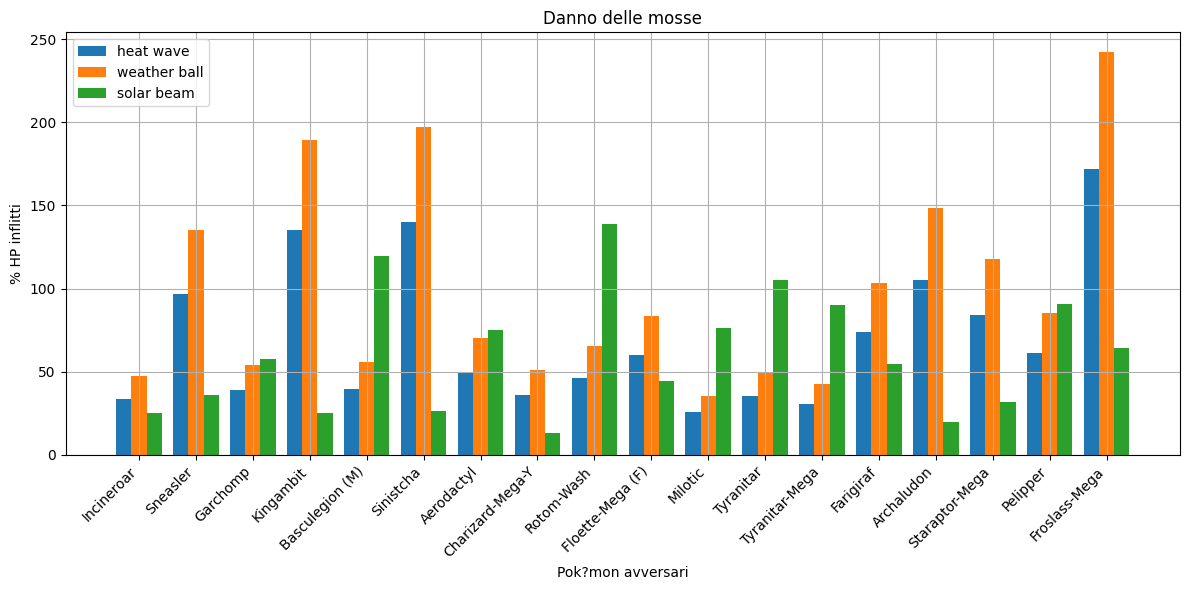

In [8]:
plot_damage_histogram(
    attacker,
    opponents
)

In [9]:
# Per ogni pokemon nella lista dei piu presenti, controlliamo quanti buoni match-up abbiamo contro.
# Buon matchup = possiamo colpire per superefficace.

team = """Rotom-Wash @ Leftovers
Ability: Levitate
Level: 50
EVs: 32 HP / 32 Def / 2 SpA
Bold Nature
- Will-O-Wisp
- Hydro Pump
- Light Screen
- Thunderbolt

Garchomp @ Yache Berry
Ability: Rough Skin
Level: 50
EVs: 13 HP / 31 Atk / 22 Spe
Adamant Nature
- Scale Shot
- Earthquake
- Rock Slide
- Protect

Kingambit @ Chople Berry
Ability: Defiant
Level: 50
EVs: 32 HP / 32 Atk / 2 SpD
Adamant Nature
- Kowtow Cleave
- Sucker Punch
- Iron Head
- Protect

Incineroar @ Sitrus Berry
Ability: Intimidate
Level: 50
EVs: 32 HP / 32 Atk / 2 Spe
Adamant Nature
- Flare Blitz
- Fake Out
- Parting Shot
- Darkest Lariat

Venusaur @ Venusaurite
Ability: Chlorophyll
Level: 50
EVs: 32 HP / 32 SpA / 2 Spe
Modest Nature
- Giga Drain
- Sludge Bomb
- Earth Power
- Protect

Dragonite @ Dragon Fang
Ability: Inner Focus
Level: 50
EVs: 2 HP / 32 Atk / 32 Spe
Adamant Nature
- Dragon Claw
- Extreme Speed
- Low Kick
- Protect
"""

team_context = build_team_context(team)
team_moves_dict = team_context["moves"]
team_item_dict = team_context["items"]
team_nature_dict = team_context["natures"]
team_ev_string = team_context["ev_strings"]

meta_counter_dict = {pokemon: [] for pokemon in meta_moves_dict.keys()}

for meta_pkmn in meta_counter_dict.keys():
    debolezze, _ = calcola_debolezze_resistenze(meta_types[meta_pkmn])

    if "rotom" in normalize_pokemon_name(meta_pkmn):
        debolezze = [tipo for tipo in debolezze if tipo != "ground"]

    for team_member, moves in team_moves_dict.items():
        for move in moves:
            move_info = get_move_data_cached(move)

            if move_info is None:
                continue

            if move_info["power"] is None and normalize_name(move) != "low-kick":
                continue

            if move_info["type"] in debolezze:
                meta_counter_dict[meta_pkmn].append(team_member)
                break

    meta_counter_dict[meta_pkmn] = sorted(set(meta_counter_dict[meta_pkmn]))

sorted_items = sorted(meta_counter_dict.items(), key=lambda item: len(item[1]), reverse=True)
sorted_items

[('Tyranitar',
  ['Dragonite', 'Garchomp', 'Kingambit', 'Rotom-Wash', 'Venusaur']),
 ('Tyranitar-Mega',
  ['Dragonite', 'Garchomp', 'Kingambit', 'Rotom-Wash', 'Venusaur']),
 ('Incineroar', ['Dragonite', 'Garchomp', 'Rotom-Wash', 'Venusaur']),
 ('Kingambit', ['Dragonite', 'Garchomp', 'Incineroar', 'Venusaur']),
 ('Basculegion (M)', ['Incineroar', 'Kingambit', 'Rotom-Wash', 'Venusaur']),
 ('Aerodactyl', ['Garchomp', 'Kingambit', 'Rotom-Wash']),
 ('Archaludon', ['Dragonite', 'Garchomp', 'Venusaur']),
 ('Froslass-Mega', ['Garchomp', 'Incineroar', 'Kingambit']),
 ('Sneasler', ['Garchomp', 'Venusaur']),
 ('Garchomp', ['Dragonite', 'Garchomp']),
 ('Sinistcha', ['Incineroar', 'Kingambit']),
 ('Charizard-Mega-Y', ['Garchomp', 'Rotom-Wash']),
 ('Floette-Mega (F)', ['Kingambit', 'Venusaur']),
 ('Milotic', ['Rotom-Wash', 'Venusaur']),
 ('Farigiraf', ['Incineroar', 'Kingambit']),
 ('Pelipper', ['Garchomp', 'Rotom-Wash']),
 ('Rotom-Wash', ['Venusaur']),
 ('Staraptor-Mega', ['Rotom-Wash'])]